In [ ]:
# ============================================================
# COCONUT PRODUCTIVITY PREDICTION - PHASE 1
# ============================================================

# If required, run this once:
# !pip install pandas numpy matplotlib scikit-learn shap xgboost joblib


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib

warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")


# ============================================================
# 2. LOAD DATASET
# ============================================================

FILE_PATH = "dataset/trend-of-coconut-production-in-kerala(in).csv"

df = pd.read_csv(FILE_PATH)

print("Dataset Shape:", df.shape)
print("\nOriginal Columns:")
print(df.columns.tolist())

display(df.head())


Libraries imported successfully.
Dataset Shape: (67, 3)

Original Columns:
['Agriculture Year', 'Area Hectare', 'Production Million Unit']


,Agriculture Year,Area Hectare,Production Million Unit
0,1955-56,447952,3099
1,1956-57,459733,3132
2,1957-58,463282,3199
3,1958-59,475690,3248
4,1959-60,492550,3365


In [4]:
# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

print("\nCleaned Columns:")
print(df.columns.tolist())


Cleaned Columns:
['agriculture_year', 'area_hectare', 'production_million_unit']


In [5]:
# ============================================================
# 4. CHECK DATA
# ============================================================

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())


# ============================================================
# 5. CREATE NUMERICAL YEAR
# ============================================================

df["year"] = (
    df["agriculture_year"]
    .astype(str)
    .str[:4]
    .astype(int)
)

print("\nYear conversion:")
display(df[["agriculture_year", "year"]].head())


# ============================================================
# 6. CALCULATE ANNUAL COCONUT PRODUCTIVITY
# ============================================================

df["productivity"] = (
    df["production_million_unit"] /
    df["area_hectare"]
)

print("\nProductivity calculated successfully.")

display(
    df[
        [
            "agriculture_year",
            "area_hectare",
            "production_million_unit",
            "productivity"
        ]
    ].head(10)
)




Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   agriculture_year         67 non-null     object
 1   area_hectare             67 non-null     int64 
 2   production_million_unit  67 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.7+ KB

Missing Values:
agriculture_year           0
area_hectare               0
production_million_unit    0
dtype: int64

Duplicate Rows:
0

Statistical Summary:


,area_hectare,production_million_unit
count,67.000000,67.000000
mean,738620.343284,4400.507463
std,132490.087811,1106.679436
min,447952.000000,2602.000000
25%,670498.000000,3324.000000
50%,760776.000000,4215.000000
75%,847617.500000,5431.500000
max,925783.000000,6326.000000



Year conversion:


,agriculture_year,year
0,1955-56,1955
1,1956-57,1956
2,1957-58,1957
3,1958-59,1958
4,1959-60,1959



Productivity calculated successfully.


,agriculture_year,area_hectare,production_million_unit,productivity
0,1955-56,447952,3099,0.006918
1,1956-57,459733,3132,0.006813
2,1957-58,463282,3199,0.006905
3,1958-59,475690,3248,0.006828
4,1959-60,492550,3365,0.006832
5,1960-61,500769,3220,0.006430
6,1961-62,504829,3247,0.006432
7,1962-63,539270,3305,0.006129
8,1963-64,544896,3262,0.005986
9,1964-65,558991,3278,0.005864


In [6]:
# ============================================================
# 7. HANDLE INVALID VALUES
# ============================================================

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.dropna()

df = df.sort_values("year").reset_index(drop=True)

print("\nFinal Dataset Shape:", df.shape)


Final Dataset Shape: (67, 5)


In [7]:
# ============================================================
# 8. PRODUCTIVITY STATISTICS
# ============================================================

print("\nProductivity Statistics:")
print(df["productivity"].describe())


Productivity Statistics:
count    67.000000
mean      0.005949
std       0.000933
min       0.003814
25%       0.005198
50%       0.005885
75%       0.006847
max       0.007491
Name: productivity, dtype: float64


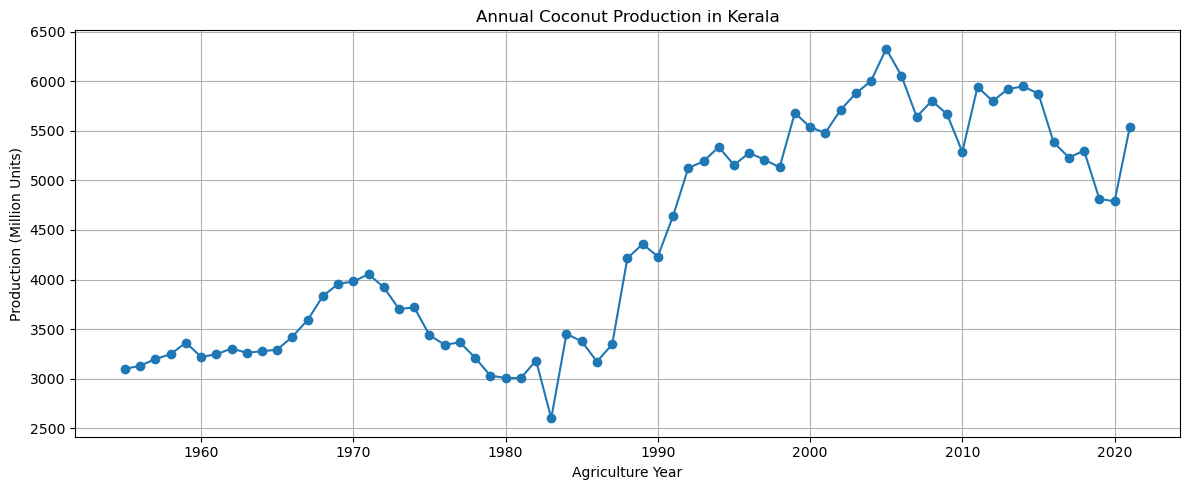

In [8]:
# ============================================================
# 9. COCONUT PRODUCTION TREND
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    df["year"],
    df["production_million_unit"],
    marker="o"
)

plt.xlabel("Agriculture Year")
plt.ylabel("Production (Million Units)")
plt.title("Annual Coconut Production in Kerala")

plt.grid(True)
plt.tight_layout()
plt.show()

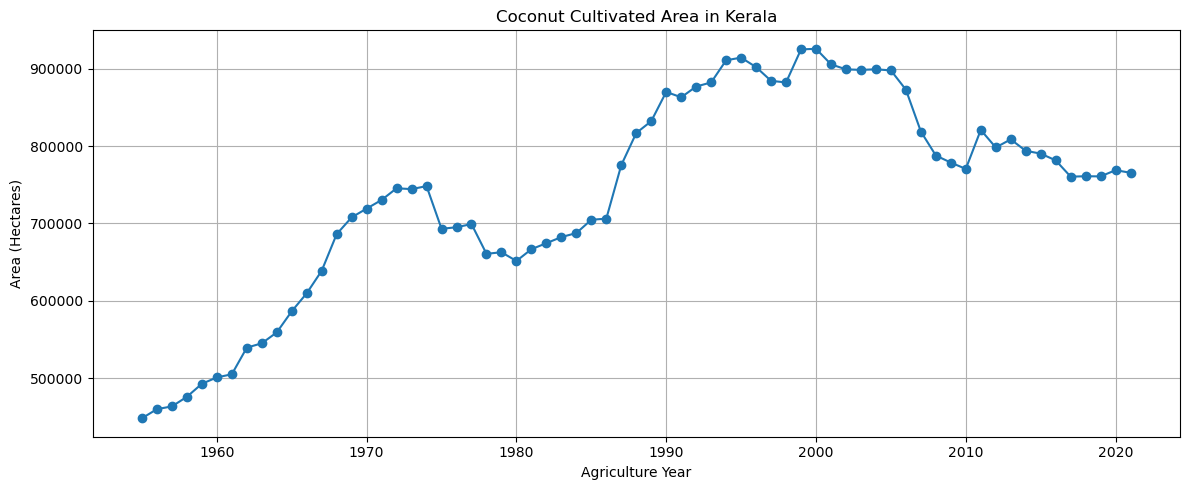

In [9]:
# ============================================================
# 10. AREA TREND
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    df["year"],
    df["area_hectare"],
    marker="o"
)

plt.xlabel("Agriculture Year")
plt.ylabel("Area (Hectares)")
plt.title("Coconut Cultivated Area in Kerala")

plt.grid(True)
plt.tight_layout()
plt.show()


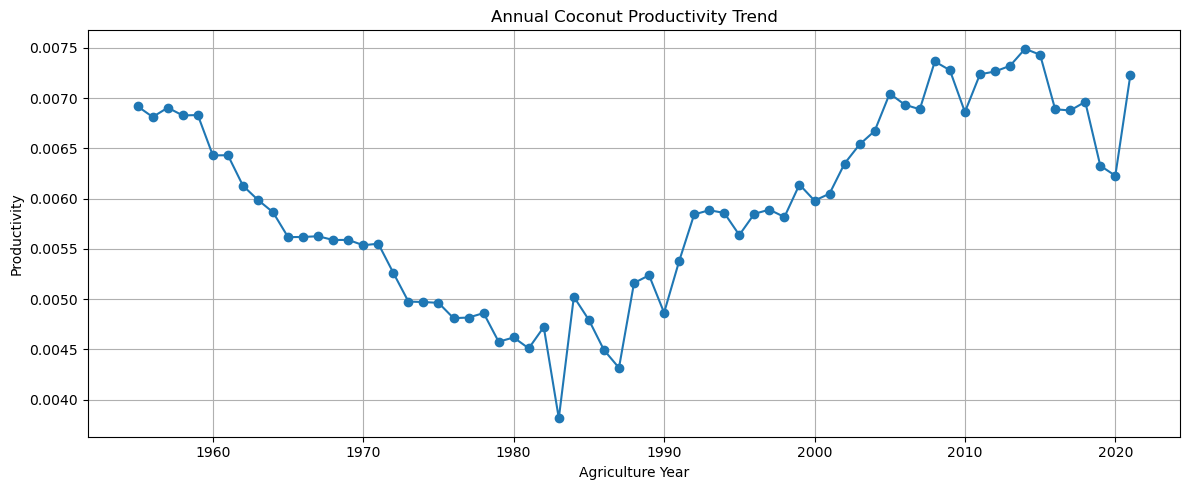

In [10]:
# ============================================================
# 11. PRODUCTIVITY TREND
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    df["year"],
    df["productivity"],
    marker="o"
)

plt.xlabel("Agriculture Year")
plt.ylabel("Productivity")
plt.title("Annual Coconut Productivity Trend")

plt.grid(True)
plt.tight_layout()
plt.show()


Correlation Matrix:


,year,area_hectare,production_million_unit,productivity
year,1.000000,0.756912,0.844877,0.418828
area_hectare,0.756912,1.000000,0.787816,0.054336
production_million_unit,0.844877,0.787816,1.000000,0.653390
productivity,0.418828,0.054336,0.653390,1.000000


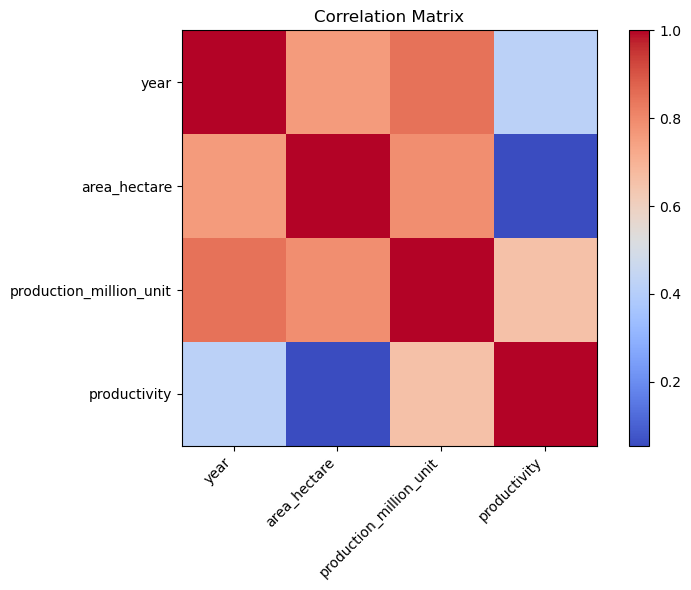

In [11]:

# ============================================================
# 12. CORRELATION MATRIX
# ============================================================

correlation = df[
    [
        "year",
        "area_hectare",
        "production_million_unit",
        "productivity"
    ]
].corr()

print("\nCorrelation Matrix:")
display(correlation)


plt.figure(figsize=(8, 6))

plt.imshow(
    correlation,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()


In [12]:
# ============================================================
# 13. DEFINE FEATURES AND TARGET
# ============================================================

# Features
X = df[
    [
        "year",
        "area_hectare"
    ]
]

# Target
y = df["productivity"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("productivity")

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


Features:
['year', 'area_hectare']

Target:
productivity

X Shape: (67, 2)
y Shape: (67,)


In [13]:
# ============================================================
# 14. CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

# IMPORTANT:
# We do NOT randomly shuffle agricultural time-series data.

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))

print(
    "\nTraining Period:",
    df.iloc[0]["agriculture_year"],
    "to",
    df.iloc[split_index - 1]["agriculture_year"]
)

print(
    "Testing Period :",
    df.iloc[split_index]["agriculture_year"],
    "to",
    df.iloc[-1]["agriculture_year"]
)


Training Samples: 53
Testing Samples : 14

Training Period: 1955-56 to 2007-08
Testing Period : 2008-09 to 2021-22


In [14]:
# ============================================================
# 15. DEFINE MACHINE LEARNING MODELS
# ============================================================

models = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=4,
        min_samples_leaf=3,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=2,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    ),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(
            kernel="rbf",
            C=10,
            gamma="scale"
        ))
    ])
}


In [15]:
# ============================================================
# 16. TIME-SERIES CROSS VALIDATION
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

print("\nPerforming Time-Series Cross Validation...\n")

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring="neg_root_mean_squared_error"
    )

    rmse_scores = -scores

    cv_results.append({
        "Model": name,
        "CV RMSE Mean": rmse_scores.mean(),
        "CV RMSE Std": rmse_scores.std()
    })

    print(
        f"{name:20s} "
        f"RMSE = {rmse_scores.mean():.6f}"
    )


Performing Time-Series Cross Validation...

Linear Regression    RMSE = 0.001206
Decision Tree        RMSE = 0.000596
Random Forest        RMSE = 0.000660
Gradient Boosting    RMSE = 0.000735
SVR                  RMSE = 0.000945


In [16]:
# ============================================================
# 17. CROSS-VALIDATION RESULTS
# ============================================================

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="CV RMSE Mean"
).reset_index(drop=True)

print("\nCross-Validation Results:")
display(cv_results_df)


# ============================================================
# 18. TRAIN ALL MODELS ON TRAINING DATA
# ============================================================

trained_models = {}
test_results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    trained_models[name] = model

    test_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })



Cross-Validation Results:


,Model,CV RMSE Mean,CV RMSE Std
0,Decision Tree,0.000596,0.000112
1,Random Forest,0.000660,0.000124
2,Gradient Boosting,0.000735,0.000257
3,SVR,0.000945,0.000351
4,Linear Regression,0.001206,0.000658


In [18]:
# ============================================================
# 19. TEST SET MODEL COMPARISON
# ============================================================

test_results_df = pd.DataFrame(test_results)

# Lower RMSE is better
test_results_df = test_results_df.sort_values(
    by="RMSE"
).reset_index(drop=True)

print("\nTest Set Results:")
display(test_results_df)

# ============================================================
# 19. TEST SET MODEL COMPARISON
# ============================================================

test_results_df = pd.DataFrame(test_results)

# Lower RMSE is better
test_results_df = test_results_df.sort_values(
    by="RMSE"
).reset_index(drop=True)

print("\nTest Set Results:")
display(test_results_df)


Test Set Results:


,Model,MAE,RMSE,R2
0,Decision Tree,0.000327,0.000388,-0.068495
1,Gradient Boosting,0.000489,0.000538,-1.050508
2,Random Forest,0.000547,0.000590,-1.464111
3,Linear Regression,0.000817,0.000899,-4.724106
4,SVR,0.001625,0.001668,-18.714799



Test Set Results:


,Model,MAE,RMSE,R2
0,Decision Tree,0.000327,0.000388,-0.068495
1,Gradient Boosting,0.000489,0.000538,-1.050508
2,Random Forest,0.000547,0.000590,-1.464111
3,Linear Regression,0.000817,0.000899,-4.724106
4,SVR,0.001625,0.001668,-18.714799


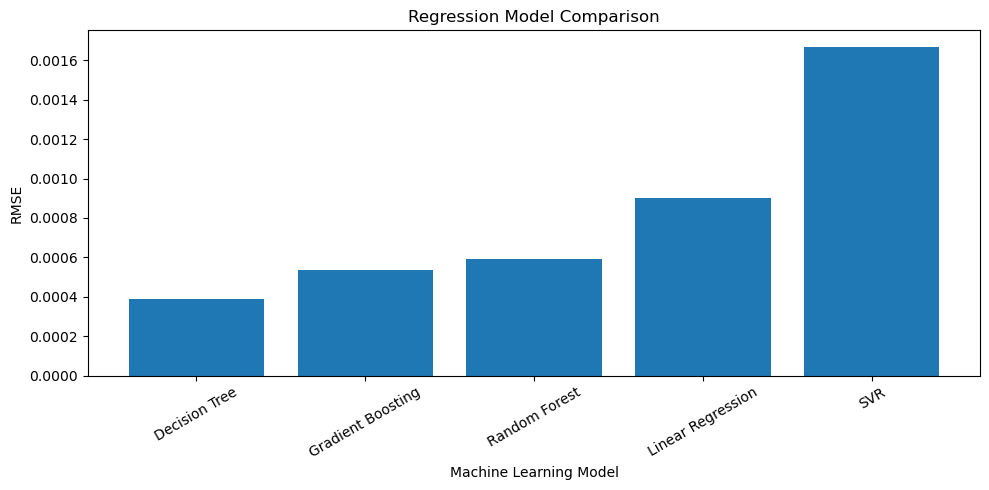

In [19]:

# ============================================================
# 20. MODEL COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    test_results_df["Model"],
    test_results_df["RMSE"]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("RMSE")
plt.title("Regression Model Comparison")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 21. SELECT BEST MODEL
# ============================================================

best_model_name = test_results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("\n====================================")
print("BEST MODEL")
print("====================================")
print(best_model_name)


# ============================================================
# 22. PREDICTIONS USING BEST MODEL
# ============================================================

best_predictions = best_model.predict(
    X_test
)

prediction_df = pd.DataFrame({

    "Agriculture Year":
        df.iloc[split_index:]["agriculture_year"].values,

    "Actual Productivity":
        y_test.values,

    "Predicted Productivity":
        best_predictions
})

print("\nActual vs Predicted:")
display(prediction_df)


BEST MODEL
Decision Tree

Actual vs Predicted:


,Agriculture Year,Actual Productivity,Predicted Productivity
0,2008-09,0.007365,0.006957
1,2009-10,0.007278,0.006957
2,2010-11,0.006862,0.006957
3,2011-12,0.007237,0.006957
4,2012-13,0.007265,0.006957
5,2013-14,0.007322,0.006957
6,2014-15,0.007491,0.006957
7,2015-16,0.007432,0.006957
8,2016-17,0.006889,0.006957
9,2017-18,0.006878,0.006957


In [21]:
# ============================================================
# 23. FINAL MODEL METRICS
# ============================================================

final_mae = mean_absolute_error(
    y_test,
    best_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

final_r2 = r2_score(
    y_test,
    best_predictions
)

print("\n====================================")
print("FINAL MODEL PERFORMANCE")
print("====================================")

print("Model :", best_model_name)
print("MAE   :", round(final_mae, 6))
print("RMSE  :", round(final_rmse, 6))
print("R²    :", round(final_r2, 6))


FINAL MODEL PERFORMANCE
Model : Decision Tree
MAE   : 0.000327
RMSE  : 0.000388
R²    : -0.068495


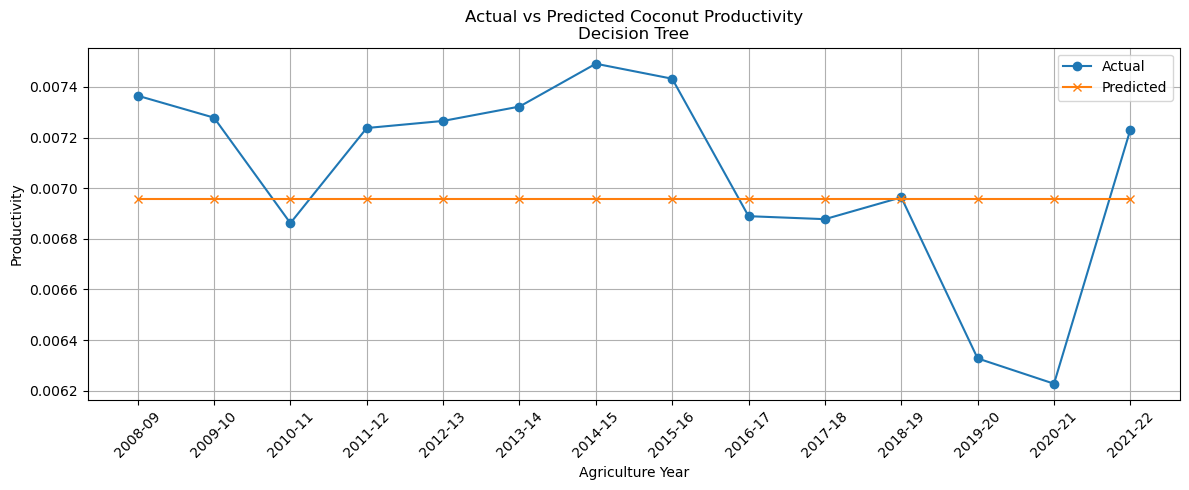

In [22]:
# ============================================================
# 24. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    prediction_df["Agriculture Year"],
    prediction_df["Actual Productivity"],
    marker="o",
    label="Actual"
)

plt.plot(
    prediction_df["Agriculture Year"],
    prediction_df["Predicted Productivity"],
    marker="x",
    label="Predicted"
)

plt.xlabel("Agriculture Year")
plt.ylabel("Productivity")

plt.title(
    f"Actual vs Predicted Coconut Productivity\n"
    f"{best_model_name}"
)

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Feature Importance:


,Feature,Importance
0,year,0.946971
1,area_hectare,0.053029


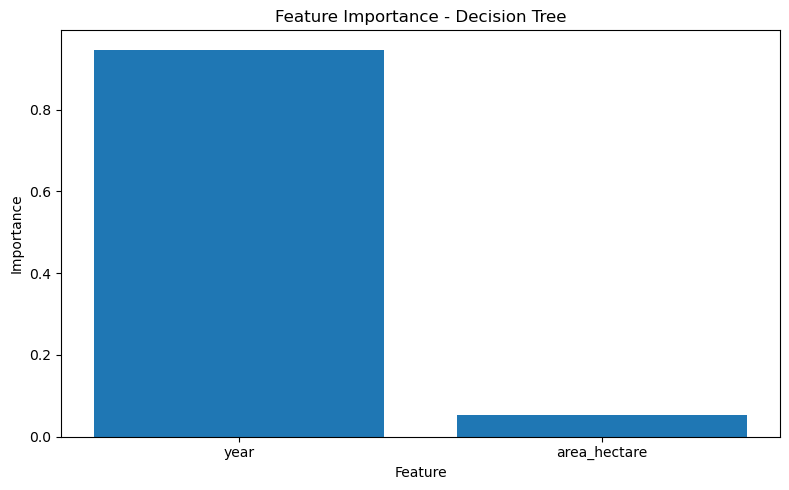

In [23]:
# ============================================================
# 25. FEATURE IMPORTANCE
# ============================================================

# Extract underlying model from Pipeline if necessary

if isinstance(best_model, Pipeline):
    underlying_model = best_model.named_steps["model"]
else:
    underlying_model = best_model


if hasattr(underlying_model, "feature_importances_"):

    importance_df = pd.DataFrame({

        "Feature": X.columns,

        "Importance":
            underlying_model.feature_importances_

    }).sort_values(
        by="Importance",
        ascending=False
    )

    print("\nFeature Importance:")
    display(importance_df)

    plt.figure(figsize=(8, 5))

    plt.bar(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.title(
        f"Feature Importance - {best_model_name}"
    )

    plt.tight_layout()
    plt.show()


In [25]:
# ============================================================
# 26. SHAP / XAI
# ============================================================

import shap

print("\nRunning SHAP analysis...")



Running SHAP analysis...



SHAP Summary:


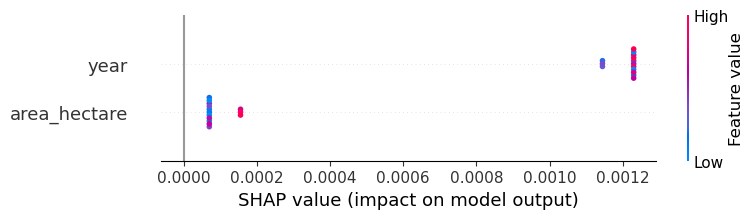


SHAP Feature Importance:


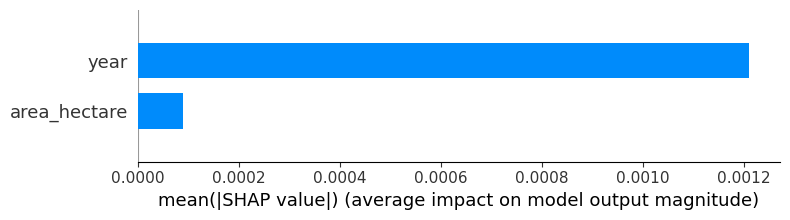


Predictions saved to 'coconut_productivity_predictions.csv'
Processed dataset saved to 'coconut_productivity_processed.csv'
Best model saved to 'best_coconut_productivity_model.pkl'


COCONUT PRODUCTIVITY ML - FINAL SUMMARY
Dataset Size       : 67 samples
Features           : ['year', 'area_hectare']
Target             : Productivity
Best Model         : Decision Tree
MAE                : 0.000327
RMSE               : 0.000388
R²                 : -0.068495
PHASE 1 COMPLETE


In [26]:
# ------------------------------------------------------------
# TREE MODELS
# ------------------------------------------------------------

if hasattr(underlying_model, "feature_importances_"):

    explainer = shap.TreeExplainer(
        underlying_model
    )

    shap_values = explainer.shap_values(
        X_test
    )

    print("\nSHAP Summary:")
    shap.summary_plot(
        shap_values,
        X_test,
        feature_names=X_test.columns
    )

    print("\nSHAP Feature Importance:")
    shap.summary_plot(
        shap_values,
        X_test,
        feature_names=X_test.columns,
        plot_type="bar"
    )


# ------------------------------------------------------------
# LINEAR REGRESSION / SVR
# ------------------------------------------------------------

else:

    # SHAP KernelExplainer works with any model.
    # Because the dataset is very small, this is acceptable.

    background = X_train.iloc[
        :min(20, len(X_train))
    ]

    explainer = shap.KernelExplainer(
        best_model.predict,
        background
    )

    shap_values = explainer.shap_values(
        X_test
    )

    print("\nSHAP Summary:")
    shap.summary_plot(
        shap_values,
        X_test,
        feature_names=X_test.columns
    )

    print("\nSHAP Feature Importance:")
    shap.summary_plot(
        shap_values,
        X_test,
        feature_names=X_test.columns,
        plot_type="bar"
    )


# ============================================================
# 27. SAVE PREDICTIONS
# ============================================================

prediction_df.to_csv(
    "coconut_productivity_predictions.csv",
    index=False
)

print(
    "\nPredictions saved to "
    "'coconut_productivity_predictions.csv'"
)


# ============================================================
# 28. SAVE PROCESSED DATASET
# ============================================================

df.to_csv(
    "coconut_productivity_processed.csv",
    index=False
)

print(
    "Processed dataset saved to "
    "'coconut_productivity_processed.csv'"
)


# ============================================================
# 29. SAVE BEST MODEL
# ============================================================

joblib.dump(
    best_model,
    "best_coconut_productivity_model.pkl"
)

print(
    "Best model saved to "
    "'best_coconut_productivity_model.pkl'"
)


# ============================================================
# 30. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("COCONUT PRODUCTIVITY ML - FINAL SUMMARY")
print("=" * 60)

print(f"Dataset Size       : {len(df)} samples")
print(f"Features           : {list(X.columns)}")
print(f"Target             : Productivity")
print(f"Best Model         : {best_model_name}")
print(f"MAE                : {final_mae:.6f}")
print(f"RMSE               : {final_rmse:.6f}")
print(f"R²                 : {final_r2:.6f}")

print("=" * 60)
print("PHASE 1 COMPLETE")
print("=" * 60)